# temporal predictions 

using encoders instead of sparse embedding settling loop in predictive coding to do autoregressive prediciton/generation task. Architecture of predictive coding based model in temporal_predictive_coding meant that pixel shfits resulted in compeltely different neurons firing in the predictive coding model, therefore resulting in chaotic embeddings and minimum cosine similarity between consecutive frames was 50% which isn't very good. Also 31% of the embedding was pure noise. This meant it was an impossible task to actually have the temporalNN learn anything beacuse the embeddings were inherently chaotic. Now use encoder instead. 

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [86]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

In [87]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    if I.ndim == 4:
        previous_num_channels = I.shape[1]
    elif I.ndim == 3:
        previous_num_channels = I.shape[0]
    else:
        previous_num_channels = 1
    r = []
    encoders = []
    deconvs = []
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        encoder = nn.Conv2d(previous_num_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False)
        nn.init.kaiming_normal_(encoder.weight, nonlinearity="relu")
        encoders.append(encoder)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs, encoders

In [88]:
class ConvGRUCell(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv_zr = nn.Conv2d(channels * 2, channels * 2, kernel_size, padding=padding)
        self.conv_h = nn.Conv2d(channels * 2, channels, kernel_size, padding=padding)

    def forward(self, x, h):
        if h is None:
            h = torch.zeros_like(x)
        zr = torch.sigmoid(self.conv_zr(torch.cat([x, h], dim=1)))
        z, r = zr.chunk(2, dim=1)
        h_tilde = torch.tanh(self.conv_h(torch.cat([x, r * h], dim=1)))
        return (1.0 - z) * h + z * h_tilde


class TemporalConvRNN(nn.Module):
    def __init__(self, r, delta_scale=0.1):
        super().__init__()
        self.delta_scale = delta_scale
        self.cells = nn.ModuleList()
        self.readouts = nn.ModuleList()
        for ri in r:
            ch = ri.shape[1]
            self.cells.append(ConvGRUCell(ch))
            readout = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
            nn.init.zeros_(readout.weight)
            nn.init.zeros_(readout.bias)
            self.readouts.append(readout)

    def init_hidden(self, r_like):
        return [torch.zeros_like(ri) for ri in r_like]

    def forward(self, r_in, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(r_in)
        r_pred, h_new, deltas = [], [], []
        for cell, readout, x, h in zip(self.cells, self.readouts, r_in, hidden):
            h_t = cell(x, h)
            delta = self.delta_scale * torch.tanh(readout(h_t))
            deltas.append(delta)
            r_pred.append(x + delta)
            h_new.append(h_t)
        return r_pred, h_new, deltas

TemporalNN = TemporalConvRNN


Training Loop

In [89]:
def encode_I(I, encoders, num_layers):
    r = [F.relu(encoders[0](I))]
    for i in range(1, num_layers):
        r.append(F.relu(encoders[i](r[i - 1])))
    return r


def _perturb_r(rs, noise_std):
    if noise_std is None or noise_std <= 0:
        return rs
    return [ri + torch.randn_like(ri) * noise_std for ri in rs]


def _cosine_slowness(r_curr, r_prev):
    loss = 0.0
    for rc, rp in zip(r_curr, r_prev):
        a = rc.reshape(1, -1)
        b = rp.reshape(1, -1)
        loss = loss + (1.0 - F.cosine_similarity(a, b).squeeze())
    return loss / len(r_curr)


def _set_requires_grad(modules, flag):
    for m in modules:
        for p in m.parameters():
            p.requires_grad = flag


def _update_temporal_params(temporal_nn, lr_u, lambda_u, max_grad_norm=1.0):
    torch.nn.utils.clip_grad_norm_(temporal_nn.parameters(), max_grad_norm)
    with torch.no_grad():
        for param in temporal_nn.parameters():
            if param.grad is not None:
                param -= lr_u * (param.grad + lambda_u * param)
                param.grad = None

In [90]:
def train_loop(I_curr, r_prev1, r_curr, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, hidden=None, r_noise_std=0.0, lambda_slow=0.1, delta_loss_weight=20.0, train_ae=True, train_gru=False):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    has_prev = r_prev1 is not None
    if r_prev1 is None:
        r_prev1 = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev1 = [ri.detach() for ri in r_prev1]

    if hidden is None:
        hidden = temporal_nn.init_hidden(r_curr)
    else:
        hidden = [hi.detach() for hi in hidden]

    h_new = hidden
    r_pred = None
    deltas = None
    delta_stats = (0.0, 0.0)
    recon_loss = torch.zeros((), device=I_curr.device)
    slow_raw = torch.zeros((), device=I_curr.device)

    for out_epoch in range(num_epochs_outer):
        if train_ae:
            r_curr = encode_I(I_curr, encoders, num_layers)
        else:
            with torch.no_grad():
                r_curr = encode_I(I_curr, encoders, num_layers)

        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        recon_loss = (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[0] ** 2)
        for j in range(1, num_layers):
            e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            recon_loss = recon_loss + (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[j] ** 2)

        if has_prev:
            slow_raw = _cosine_slowness(r_curr, r_prev1)

        total_loss = torch.zeros((), device=I_curr.device)
        if train_ae:
            total_loss = total_loss + recon_loss
            if has_prev and lambda_slow > 0:
                total_loss = total_loss + lambda_slow * slow_raw

        if train_gru and has_prev:
            r_in = _perturb_r([ri.detach() for ri in r_prev1], r_noise_std)
            h_in = [hi.detach() for hi in hidden]
            r_pred, h_new, deltas = temporal_nn(r_in, h_in)
            for j in range(num_layers):
                delta_target = (r_curr[j] - r_prev1[j]).detach()
                total_loss = total_loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")

        if train_ae:
            for j in range(num_layers):
                encoders[j].zero_grad()
                deconvs[j].zero_grad()
        if train_gru:
            temporal_nn.zero_grad()

        if total_loss.requires_grad:
            total_loss.backward()

        with torch.no_grad():
            if has_prev:
                a_norm = sum(torch.norm(r_curr[j] - r_prev1[j]).item() for j in range(num_layers))
            else:
                a_norm = 0.0
            d_norm = sum(torch.norm(d).item() for d in deltas) if deltas is not None else 0.0
            delta_stats = (d_norm, a_norm)
            if train_ae:
                for j in range(num_layers):
                    if deconvs[j].weight.requires_grad and deconvs[j].weight.grad is not None:
                        deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                        deconvs[j].weight.grad = None
                    if encoders[j].weight.requires_grad and encoders[j].weight.grad is not None:
                        encoders[j].weight -= lr_u * (encoders[j].weight.grad + lambda_u * encoders[j].weight)
                        encoders[j].weight.grad = None
        if train_gru:
            _update_temporal_params(temporal_nn, lr_u, lambda_u)

    slow_term = (lambda_slow * slow_raw) if has_prev and lambda_slow > 0 else torch.zeros(())
    loss_stats = {
        "recon": float(recon_loss.detach()),
        "slow_raw": float(slow_raw.detach()),
        "slow": float(slow_term.detach()),
    }
    h_out = [hi.detach() for hi in h_new]
    return r_curr, r_pred, h_out, delta_stats, loss_stats


sequential training

In [91]:
def rollout_temporal_loss(r_in, hidden, r_targets, temporal_nn, sigma_2, lr_u, lambda_u, r_noise_std=0.0, delta_loss_weight=20.0):
    x = _perturb_r([ri.detach() for ri in r_in], r_noise_std)
    h = [hi.detach() for hi in hidden]
    loss = 0.0
    for target in r_targets:
        r_pred, h, deltas = temporal_nn(x, h)
        for j in range(len(r_pred)):
            delta_target = (target[j] - x[j]).detach()
            loss = loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")
        x = r_pred
    temporal_nn.zero_grad()
    loss.backward()
    _update_temporal_params(temporal_nn, lr_u, lambda_u)
    return float(loss.detach())


def train_video_sequence(sequence, r_curr_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, r_noise_std=0.0, ss_p=0.0, rollout_k=1, lambda_slow=0.1, delta_loss_weight=20.0, train_ae=True, train_gru=False):
    r_prev1 = None
    hidden = None
    r_curr = r_curr_init
    r_sequence = []
    h_sequence = []
    delta_norms = []
    dr_norms = []
    recon_vals = []
    slow_raw_vals = []
    slow_vals = []

    for i, image in enumerate(sequence):
        I_curr = image.float()

        r_curr, r_pred, hidden, (d_norm, a_norm), loss_stats = train_loop(
            I_curr, r_prev1, r_curr,
            alpha, lambda_u, lr_r, lr_u, sigma_2,
            num_epochs_outer, num_epochs_inner, num_layers,
            deconvs, encoders, temporal_nn,
            hidden=hidden,
            r_noise_std=r_noise_std,
            lambda_slow=lambda_slow,
            delta_loss_weight=delta_loss_weight,
            train_ae=train_ae,
            train_gru=train_gru,
        )

        recon_vals.append(loss_stats["recon"])
        slow_raw_vals.append(loss_stats["slow_raw"])
        slow_vals.append(loss_stats["slow"])

        if r_prev1 is not None and a_norm > 0:
            delta_norms.append(d_norm)
            dr_norms.append(a_norm)

        r_sequence.append([ri.detach().clone() for ri in r_curr])
        h_sequence.append([hi.detach().clone() for hi in hidden])

        if train_gru and r_prev1 is not None and r_pred is not None and np.random.rand() < ss_p:
            r_prev1 = [ri.detach().clone() for ri in r_pred]
        else:
            r_prev1 = [ri.detach() for ri in r_curr]

    if train_gru and rollout_k > 1 and len(r_sequence) >= 1 + rollout_k:
        for t in range(1, len(r_sequence) - rollout_k + 1):
            rollout_temporal_loss(
                r_sequence[t - 1],
                h_sequence[t - 1],
                r_sequence[t:t + rollout_k],
                temporal_nn,
                sigma_2,
                lr_u,
                lambda_u,
                r_noise_std=r_noise_std,
                delta_loss_weight=delta_loss_weight,
            )

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    return r_sequence, {
        "delta_norm": mean_delta,
        "dr_norm": mean_dr,
        "ratio": ratio,
        "recon": sum(recon_vals) / max(len(recon_vals), 1),
        "slow_raw": sum(slow_raw_vals) / max(len(slow_raw_vals), 1),
        "slow": sum(slow_vals) / max(len(slow_vals), 1),
    }


validation


In [92]:
def validate_heirarchical(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders,temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []
    I_prev = None

    delta_norms = []
    dr_norms = []
    mse_vs_curr = []
    mse_vs_prev = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())
                mse_vs_curr.append(torch.mean((I_hat - I_curr) ** 2).item())
                if I_prev is not None:
                    mse_vs_prev.append(torch.mean((I_hat - I_prev) ** 2).item())

            r_curr = encode_I(I_curr, encoders, num_layers)

            if t >= 1:
                d_norm = 0.0
                a_norm = 0.0
                for i in range(num_layers):
                    d_norm += torch.norm(deltas[i]).item()
                    a_norm += torch.norm(r_curr[i] - r_prev1_use[i]).item()
                delta_norms.append(d_norm)
                dr_norms.append(a_norm)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]
        I_prev = I_curr.detach().clone()

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    mean_mse_curr = sum(mse_vs_curr) / max(len(mse_vs_curr), 1)
    mean_mse_prev = sum(mse_vs_prev) / max(len(mse_vs_prev), 1)
    motion_gap = mean_mse_curr - mean_mse_prev
    print(f"Identity check | ||delta||={mean_delta:.6f}  ||r_t-r_(t-1)||={mean_dr:.6f}  ratio={ratio:.4f}  delta_scale={temporal_nn.delta_scale}")
    # COPY/MOTION only meaningful once grounded preds look like digits (low MSE)
    if mean_mse_curr < 0.1:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  MSE(pred,true_(t-1))={mean_mse_prev:.6f}  gap={motion_gap:+.6f}  {'COPY' if motion_gap > 0 else 'MOTION'}")
    else:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  (skip COPY/MOTION — preds not digit-like yet)")

    return mse, mse_per_frame, true_frames, pred_frames, r_curr, motion_gap, ratio


def validate_recon(seq, deconvs, encoders, num_layers):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    trues, recons = [], []
    with torch.no_grad():
        for t in range(seq.shape[0]):
            I = seq[t] - seq[t].mean()
            if I.ndim == 3:
                I = I.unsqueeze(0)
            r = encode_I(I, encoders, num_layers)
            I_hat = f(deconvs[0](r[0]))
            trues.append(I.detach().clone())
            recons.append(I_hat.detach().clone())
    trues = torch.stack(trues, dim=0)
    recons = torch.stack(recons, dim=0)
    mse = torch.mean((trues - recons) ** 2)
    return mse, trues, recons




def _flat_r(r_list):
    return torch.cat([ri.reshape(-1) for ri in r_list])


def _pair_stats(ra, rb):
    a, b = _flat_r(ra), _flat_r(rb)
    cos = F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()
    rel = (torch.norm(a - b) / (torch.norm(a) + 1e-8)).item()
    abs_dist = torch.norm(a - b).item()
    return cos, rel, abs_dist


def diagnose_latent_smoothness(seq, unrelated_frames, encoders, num_layers, max_unrelated_pairs=40, label=""):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    tag = label or "encoder"

    print("\n" + "=" * 60)
    print(f"B. Latent smoothness [{tag}]")
    print("=" * 60)

    rs = []
    with torch.no_grad():
        I0 = seq[0]
        if I0.ndim == 3:
            I0 = I0.unsqueeze(0)
        I0 = I0 - I0.mean()
        ra = encode_I(I0, encoders, num_layers)
        rb = encode_I(I0, encoders, num_layers)
        same_cos, _, _ = _pair_stats(ra, rb)
        print(f"Same-frame cos={same_cos:.4f}  (must be 1.0)")
        for t in range(T):
            I_curr = seq[t]
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)
            I_curr = I_curr - I_curr.mean()
            rs.append([ri.detach().clone() for ri in encode_I(I_curr, encoders, num_layers)])

    cons_cos, cons_rel, cons_abs = [], [], []
    print(f"\n{'t':>4}  {'cos(r_t,r_t-1)':>14}  {'||dr||/||r_t||':>14}  {'||dr||':>10}")
    for t in range(1, T):
        cos, rel, abs_d = _pair_stats(rs[t], rs[t - 1])
        cons_cos.append(cos)
        cons_rel.append(rel)
        cons_abs.append(abs_d)
        print(f"{t:4d}  {cos:14.4f}  {rel:14.4f}  {abs_d:10.4f}")

    u_rs = []
    with torch.no_grad():
        for I in unrelated_frames:
            I_u = I.float()
            if I_u.ndim == 3:
                I_u = I_u.unsqueeze(0)
            I_u = I_u - I_u.mean()
            u_rs.append([ri.detach().clone() for ri in encode_I(I_u, encoders, num_layers)])

    un_cos, un_rel, un_abs = [], [], []
    n_u = len(u_rs)
    pairs = [(i, j) for i in range(n_u) for j in range(i + 1, n_u)]
    if len(pairs) > max_unrelated_pairs:
        idx = torch.randperm(len(pairs))[:max_unrelated_pairs].tolist()
        pairs = [pairs[k] for k in idx]
    for i, j in pairs:
        cos, rel, abs_d = _pair_stats(u_rs[i], u_rs[j])
        un_cos.append(cos)
        un_rel.append(rel)
        un_abs.append(abs_d)

    m_cc, m_cr, m_ca = np.mean(cons_cos), np.mean(cons_rel), np.mean(cons_abs)
    m_uc, m_ur, m_ua = np.mean(un_cos), np.mean(un_rel), np.mean(un_abs)
    frac_rel = m_cr / (m_ur + 1e-8)
    frac_abs = m_ca / (m_ua + 1e-8)

    print(f"\nConsecutive ({tag}):  cos={m_cc:.4f}  rel={m_cr:.4f}  ||dr||={m_ca:.4f}")
    print(f"Unrelated frames:      cos={m_uc:.4f}  rel={m_ur:.4f}  ||dr||={m_ua:.4f}")
    print(f"consec/unrelated:      rel={frac_rel:.3f}  abs={frac_abs:.3f}")
    if frac_rel > 0.7:
        print("VERDICT: NON-SMOOTH — consecutive ≈ unrelated.")
    elif frac_rel > 0.4:
        print("VERDICT: moderately jumpy.")
    else:
        print("VERDICT: usable — consecutive clearly closer than unrelated.")
    return {
        "cons_cos": m_cc, "cons_rel": m_cr, "cons_abs": m_ca,
        "un_cos": m_uc, "un_rel": m_ur, "un_abs": m_ua,
        "frac_rel": frac_rel, "frac_abs": frac_abs, "tag": tag,
    }



In [93]:
def validate_heirarchical_long(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn, split_point=10):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

            if t >= split_point:
                I_obs = pred_frames[t - 1] - pred_frames[t - 1].mean()
                if I_obs.ndim == 3:
                    I_obs = I_obs.unsqueeze(0)
                if t == split_point:
                    sat_true = (I_curr.abs() > 0.99).float().mean().item()
                    sat_sub = (I_obs.abs() > 0.99).float().mean().item()
                    print(f"t={t} saturation | true: {sat_true:.4f} | substitute: {sat_sub:.4f}")
            else:
                I_obs = I_curr

            r_curr = encode_I(I_obs, encoders, num_layers)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr






In [94]:
def _plot_pairs(true_frames, other_frames, row2="Pred"):
    n_show = true_frames.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {t + 1}")
        axes[0, t].axis("off")
        axes[1, t].imshow(other_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"{row2} {t + 1}")
        axes[1, t].axis("off")
    plt.show()


def main():
    num_data = 20
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_ae_epochs = 60
    num_ae_epochs_pre = 30
    num_gru_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lambda_slow = 0.0
    delta_loss_weight = 100.0
    lr_r = 0.02
    lr_U = 0.01
    sigma_2 = 1.0
    num_layers = 2
    r_noise_std_start = 0.0
    r_noise_std_end = 0.05
    ss_p_start = 0.0
    ss_p_end = 0.4
    rollout_k = 4
    num_epochs_inner = 200
    num_epochs_outer = 1

    print("=" * 60)
    print(f"Stage A: {num_ae_epochs} AE epochs | Stage B: {num_gru_epochs} GRU epochs | {num_data} sequences")
    print(f"Cosine slowness λ={lambda_slow}  lr_U={lr_U}  lambda_u={lambda_u}")
    print("=" * 60)

    _, r_init, deconvs, encoders = make_variables(sequences[0][0], num_layers=num_layers)
    temporal_nn = TemporalConvRNN(r_init, delta_scale=1.0)
    print(f"delta_scale={temporal_nn.delta_scale}  grad_clip=1.0  delta_loss={delta_loss_weight}*mean")

    _unrelated = [input_data[i][0].float() / 255.0 for i in range(num_data, num_data + 8)]

    print("\n" + "#" * 60)
    print("STAGE A — train encoder + decoder only (recon + cosine slowness)")
    print("#" * 60)
    _set_requires_grad(encoders + deconvs, True)
    for p in temporal_nn.parameters():
        p.requires_grad = False

    for epoch in range(num_ae_epochs):
        if epoch >= num_ae_epochs_pre:
            lambda_slow = 0.05
        epoch_recon, epoch_slow_raw, epoch_slow = [], [], []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn,
                r_noise_std=0.0, ss_p=0.0, rollout_k=1,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
                train_ae=True,
                train_gru=False,
            )
            epoch_recon.append(train_stats["recon"])
            epoch_slow_raw.append(train_stats["slow_raw"])
            epoch_slow.append(train_stats["slow"])

        recon_mse, true_frames, recon_frames = validate_recon(sequences[0], deconvs, encoders, num_layers)
        print(
            f"[A {epoch:03d}/{num_ae_epochs:03d}]  L_recon={sum(epoch_recon)/len(epoch_recon):.5f}  "
            f"L_slow_raw={sum(epoch_slow_raw)/len(epoch_slow_raw):.5f}  "
            f"λL_slow={sum(epoch_slow)/len(epoch_slow):.5f}  "
            f"recon MSE={float(recon_mse):.6f}"
        )
        if epoch % 5 == 0 or epoch == num_ae_epochs - 1:
            _plot_pairs(true_frames, recon_frames, row2="Recon")

    diagnose_latent_smoothness(
        sequences[0], _unrelated, encoders, num_layers,
        label="after stage A",
    )

    print("\n" + "#" * 60)
    print("STAGE B — freeze encoder + decoder, train GRU only")
    print("#" * 60)
    _set_requires_grad(encoders + deconvs, False)
    for p in temporal_nn.parameters():
        p.requires_grad = True

    for epoch in range(num_gru_epochs):
        frac = epoch / max(num_gru_epochs - 1, 1)
        r_noise_std = r_noise_std_start + (r_noise_std_end - r_noise_std_start) * frac
        ss_p = ss_p_start + (ss_p_end - ss_p_start) * frac
        epoch_ratios = []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn,
                r_noise_std=r_noise_std, ss_p=ss_p, rollout_k=rollout_k,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
                train_ae=False,
                train_gru=True,
            )
            epoch_ratios.append(train_stats["ratio"])

        train_ratio = sum(epoch_ratios) / max(len(epoch_ratios), 1)
        mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
            sequences[0], r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
        )
        print(
            f"[B {epoch:03d}/{num_gru_epochs:03d}]  r_noise={r_noise_std:.4f}  ss_p={ss_p:.3f}  "
            f"Next-frame MSE: {mse:.6f}  train_δ-ratio={train_ratio:.4f}  val_δ-ratio={val_ratio:.4f}"
        )
        if epoch % 5 == 0 or epoch == num_gru_epochs - 1:
            _plot_pairs(true_frames, pred_frames, row2="Pred")

    print("\nPost-train latent smoothness (frozen encoder):")
    diagnose_latent_smoothness(
        sequences[0], _unrelated, encoders, num_layers,
        label="after stage B",
    )

    val_seq = input_data[num_data].float() / 255.0
    recon_mse, true_recon, recon_frames = validate_recon(val_seq, deconvs, encoders, num_layers)
    print(f"Held-out grounded recon MSE: {float(recon_mse):.6f}")
    _plot_pairs(true_recon, recon_frames, row2="Recon")

    mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Validation  ->  Next-frame MSE: {mse:.6f}  δ-ratio={val_ratio:.4f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")
    _plot_pairs(true_frames, pred_frames, row2="Pred")

    temporal_nn.eval()
    mse_lr, mse_per_frame_lr, true_frames_lr, pred_frames_lr, _ = validate_heirarchical_long(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Long-run  ->  MSE: {mse_lr:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame_lr.tolist()]}")
    _plot_pairs(true_frames_lr, pred_frames_lr, row2="Pred")


Stage A: 60 AE epochs | Stage B: 20 GRU epochs | 20 sequences
Cosine slowness λ=0.0  lr_U=0.01  lambda_u=0.001
delta_scale=1.0  grad_clip=1.0  delta_loss=100.0*mean

############################################################
STAGE A — train encoder + decoder only (recon + cosine slowness)
############################################################
[A 000/060]  L_recon=0.06112  L_slow_raw=0.43008  λL_slow=0.00000  recon MSE=0.029847


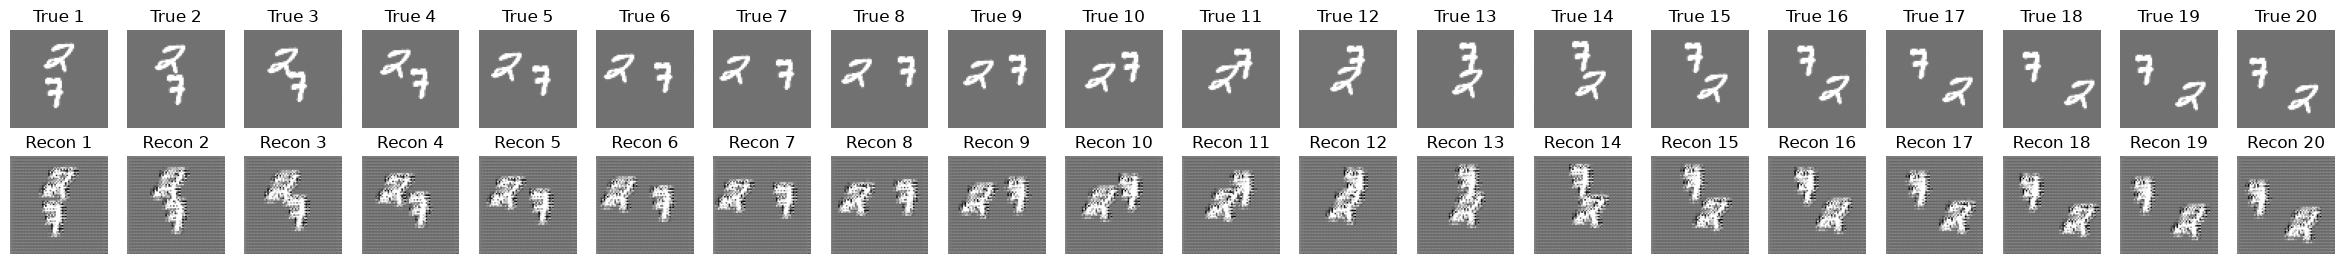

[A 001/060]  L_recon=0.03036  L_slow_raw=0.43132  λL_slow=0.00000  recon MSE=0.020307
[A 002/060]  L_recon=0.02443  L_slow_raw=0.42886  λL_slow=0.00000  recon MSE=0.016182
[A 003/060]  L_recon=0.02064  L_slow_raw=0.42484  λL_slow=0.00000  recon MSE=0.013612
[A 004/060]  L_recon=0.01795  L_slow_raw=0.42051  λL_slow=0.00000  recon MSE=0.011857
[A 005/060]  L_recon=0.01599  L_slow_raw=0.41658  λL_slow=0.00000  recon MSE=0.010572


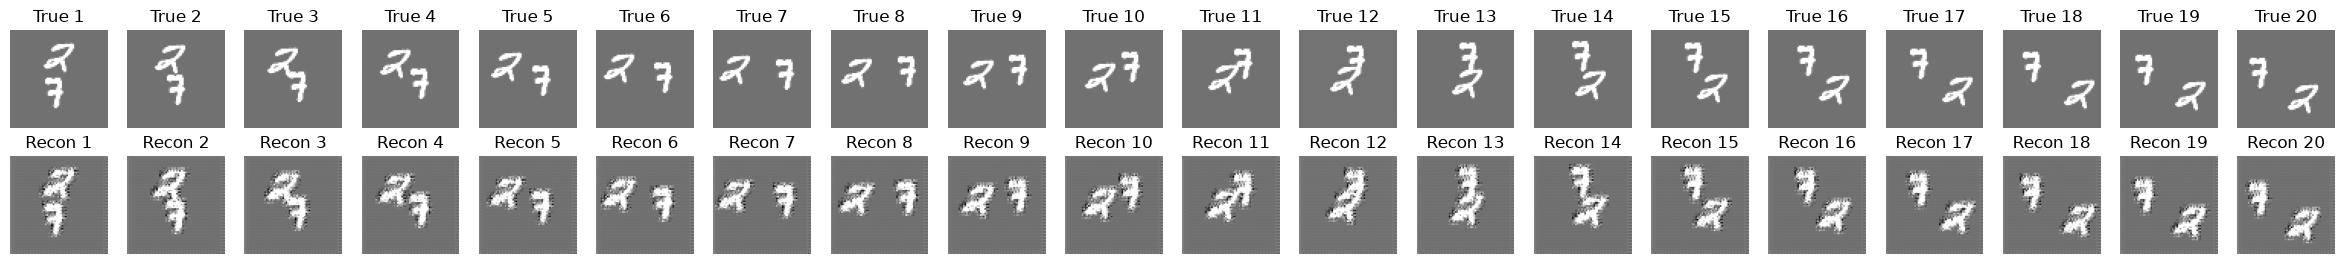

[A 006/060]  L_recon=0.01452  L_slow_raw=0.41337  λL_slow=0.00000  recon MSE=0.009585
[A 007/060]  L_recon=0.01338  L_slow_raw=0.41088  λL_slow=0.00000  recon MSE=0.008799
[A 008/060]  L_recon=0.01248  L_slow_raw=0.40902  λL_slow=0.00000  recon MSE=0.008159
[A 009/060]  L_recon=0.01173  L_slow_raw=0.40767  λL_slow=0.00000  recon MSE=0.007626
[A 010/060]  L_recon=0.01110  L_slow_raw=0.40670  λL_slow=0.00000  recon MSE=0.007172


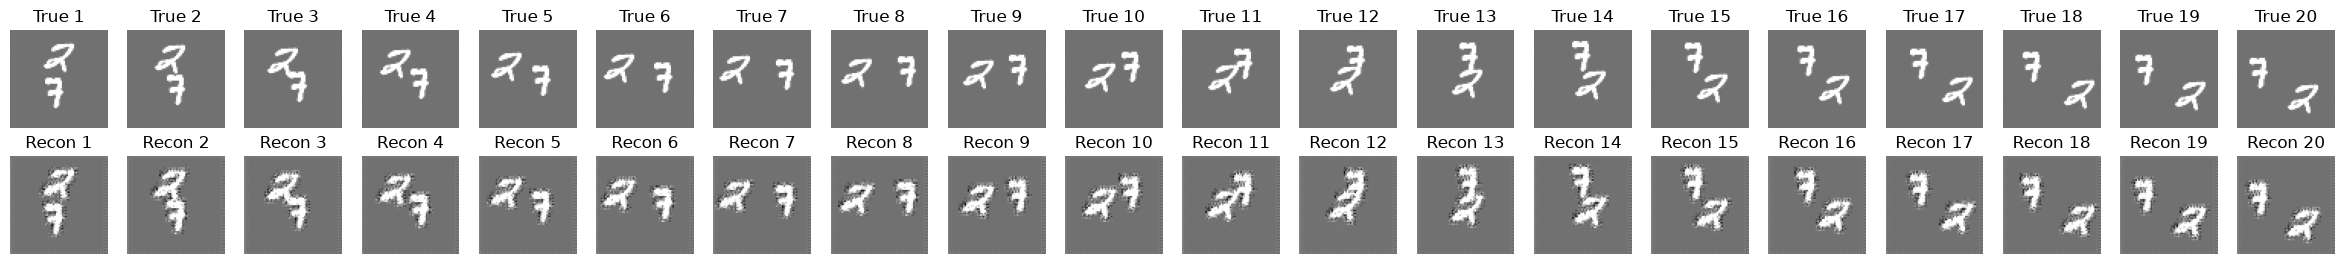

[A 011/060]  L_recon=0.01056  L_slow_raw=0.40600  λL_slow=0.00000  recon MSE=0.006775
[A 012/060]  L_recon=0.01008  L_slow_raw=0.40551  λL_slow=0.00000  recon MSE=0.006425
[A 013/060]  L_recon=0.00965  L_slow_raw=0.40516  λL_slow=0.00000  recon MSE=0.006114
[A 014/060]  L_recon=0.00926  L_slow_raw=0.40490  λL_slow=0.00000  recon MSE=0.005835
[A 015/060]  L_recon=0.00891  L_slow_raw=0.40471  λL_slow=0.00000  recon MSE=0.005584


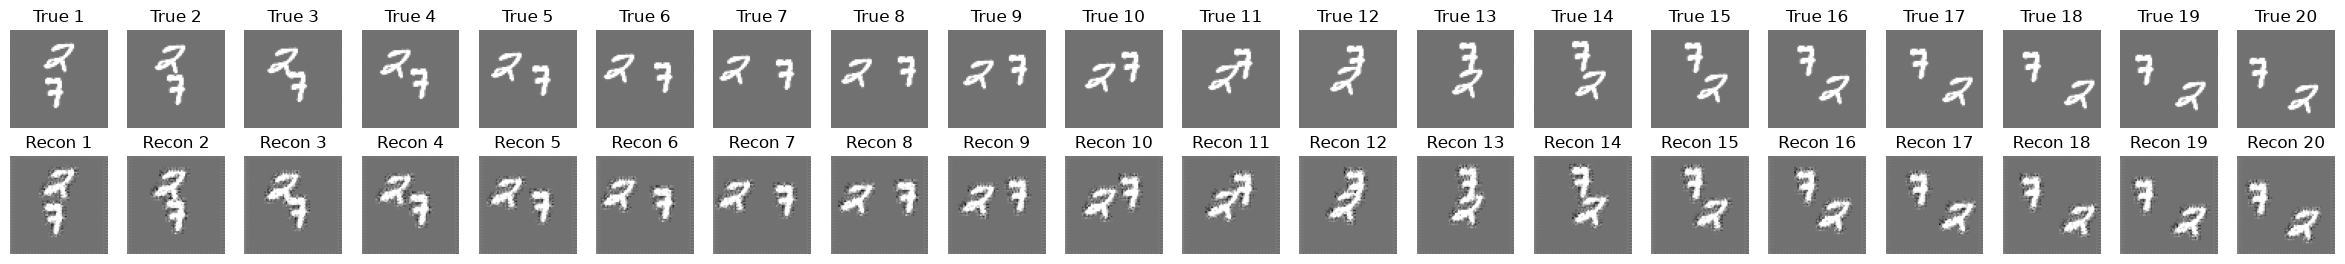

[A 016/060]  L_recon=0.00859  L_slow_raw=0.40455  λL_slow=0.00000  recon MSE=0.005357
[A 017/060]  L_recon=0.00829  L_slow_raw=0.40442  λL_slow=0.00000  recon MSE=0.005153
[A 018/060]  L_recon=0.00802  L_slow_raw=0.40429  λL_slow=0.00000  recon MSE=0.004964
[A 019/060]  L_recon=0.00776  L_slow_raw=0.40418  λL_slow=0.00000  recon MSE=0.004791
[A 020/060]  L_recon=0.00752  L_slow_raw=0.40405  λL_slow=0.00000  recon MSE=0.004633


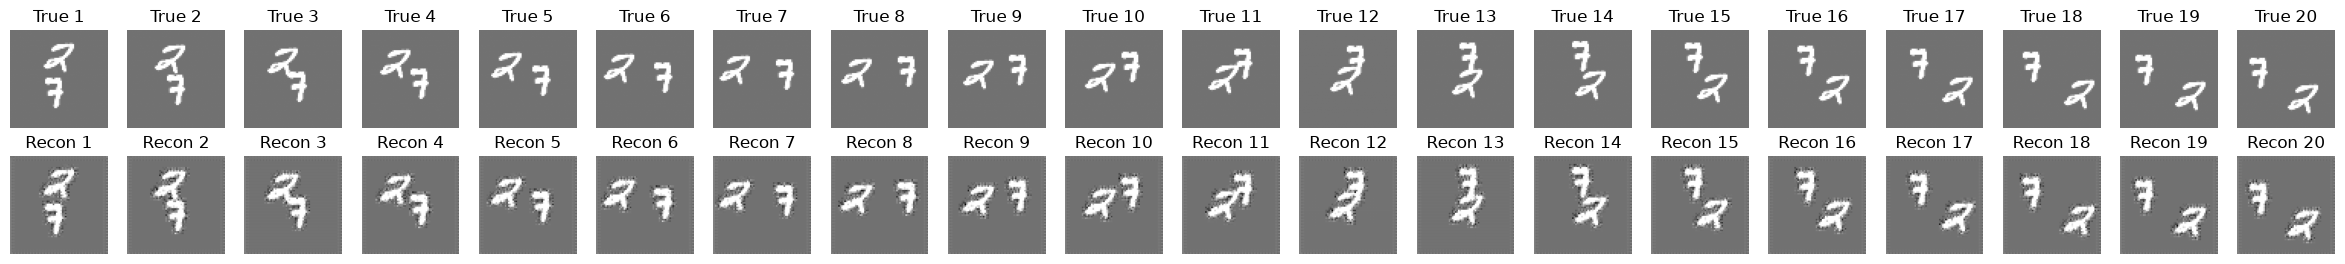

[A 021/060]  L_recon=0.00730  L_slow_raw=0.40393  λL_slow=0.00000  recon MSE=0.004487
[A 022/060]  L_recon=0.00709  L_slow_raw=0.40379  λL_slow=0.00000  recon MSE=0.004350
[A 023/060]  L_recon=0.00689  L_slow_raw=0.40363  λL_slow=0.00000  recon MSE=0.004223
[A 024/060]  L_recon=0.00670  L_slow_raw=0.40347  λL_slow=0.00000  recon MSE=0.004104
[A 025/060]  L_recon=0.00652  L_slow_raw=0.40329  λL_slow=0.00000  recon MSE=0.003992


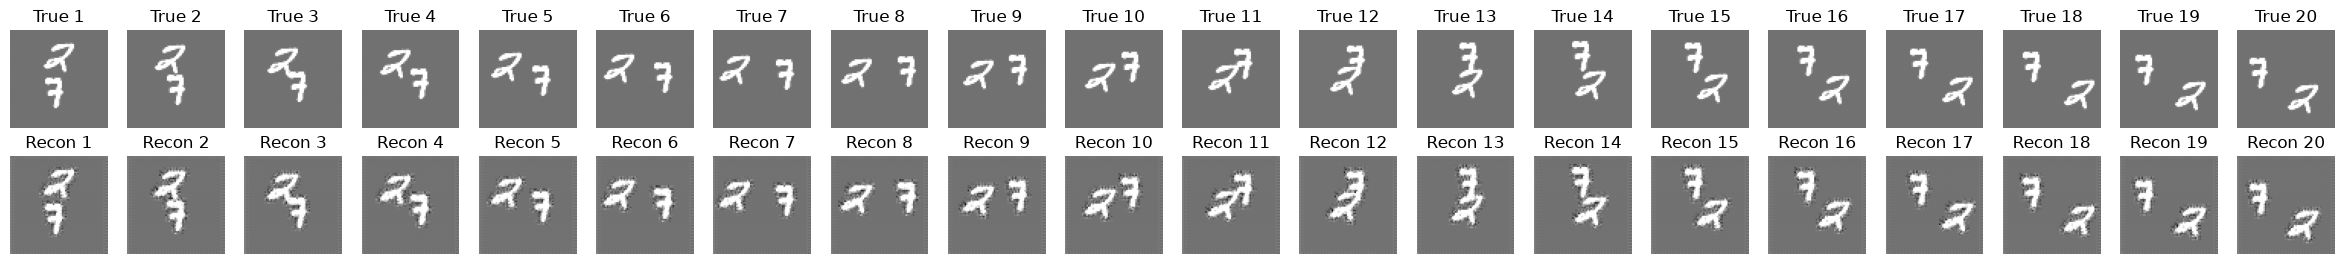

[A 026/060]  L_recon=0.00636  L_slow_raw=0.40308  λL_slow=0.00000  recon MSE=0.003888
[A 027/060]  L_recon=0.00620  L_slow_raw=0.40285  λL_slow=0.00000  recon MSE=0.003790
[A 028/060]  L_recon=0.00605  L_slow_raw=0.40260  λL_slow=0.00000  recon MSE=0.003698
[A 029/060]  L_recon=0.00590  L_slow_raw=0.40234  λL_slow=0.00000  recon MSE=0.003612
[A 030/060]  L_recon=0.00576  L_slow_raw=0.39880  λL_slow=0.01994  recon MSE=0.003524


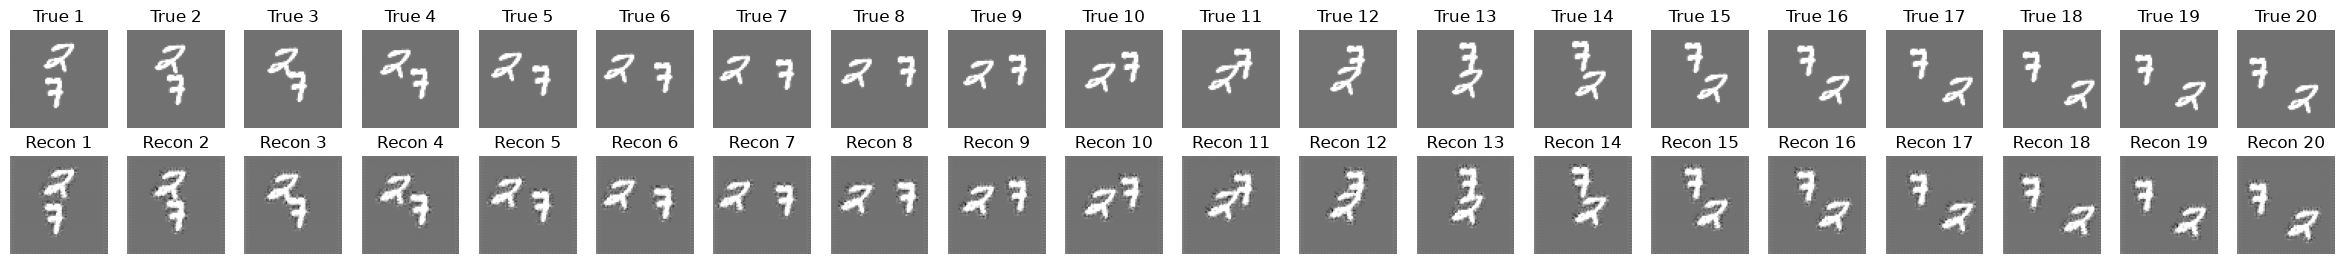

[A 031/060]  L_recon=0.00563  L_slow_raw=0.39236  λL_slow=0.01962  recon MSE=0.003445
[A 032/060]  L_recon=0.00551  L_slow_raw=0.38651  λL_slow=0.01933  recon MSE=0.003370
[A 033/060]  L_recon=0.00540  L_slow_raw=0.38114  λL_slow=0.01906  recon MSE=0.003301
[A 034/060]  L_recon=0.00529  L_slow_raw=0.37614  λL_slow=0.01881  recon MSE=0.003236
[A 035/060]  L_recon=0.00518  L_slow_raw=0.37144  λL_slow=0.01857  recon MSE=0.003173


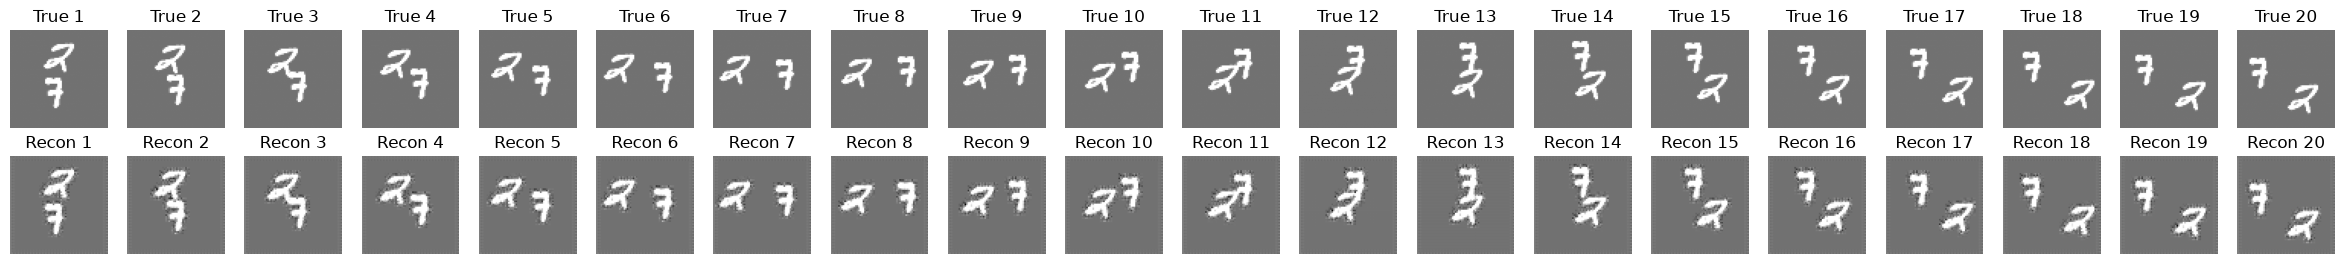

[A 036/060]  L_recon=0.00508  L_slow_raw=0.36700  λL_slow=0.01835  recon MSE=0.003114
[A 037/060]  L_recon=0.00498  L_slow_raw=0.36277  λL_slow=0.01814  recon MSE=0.003057
[A 038/060]  L_recon=0.00488  L_slow_raw=0.35872  λL_slow=0.01794  recon MSE=0.003004
[A 039/060]  L_recon=0.00479  L_slow_raw=0.35483  λL_slow=0.01774  recon MSE=0.002954
[A 040/060]  L_recon=0.00470  L_slow_raw=0.35108  λL_slow=0.01755  recon MSE=0.002906


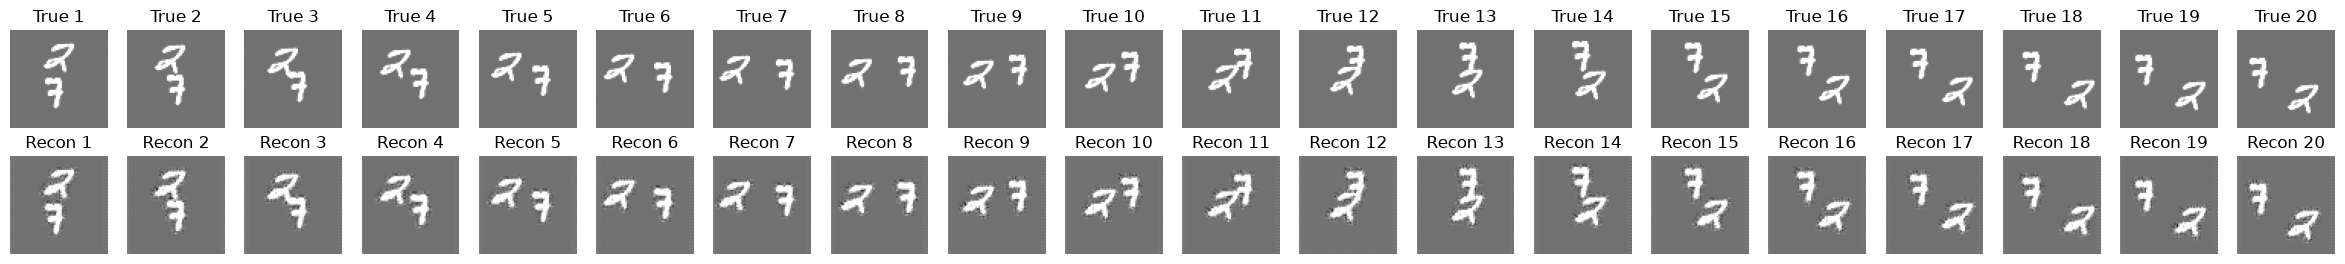

[A 041/060]  L_recon=0.00461  L_slow_raw=0.34747  λL_slow=0.01737  recon MSE=0.002862
[A 042/060]  L_recon=0.00453  L_slow_raw=0.34396  λL_slow=0.01720  recon MSE=0.002820
[A 043/060]  L_recon=0.00445  L_slow_raw=0.34056  λL_slow=0.01703  recon MSE=0.002780
[A 044/060]  L_recon=0.00437  L_slow_raw=0.33725  λL_slow=0.01686  recon MSE=0.002743
[A 045/060]  L_recon=0.00429  L_slow_raw=0.33404  λL_slow=0.01670  recon MSE=0.002707


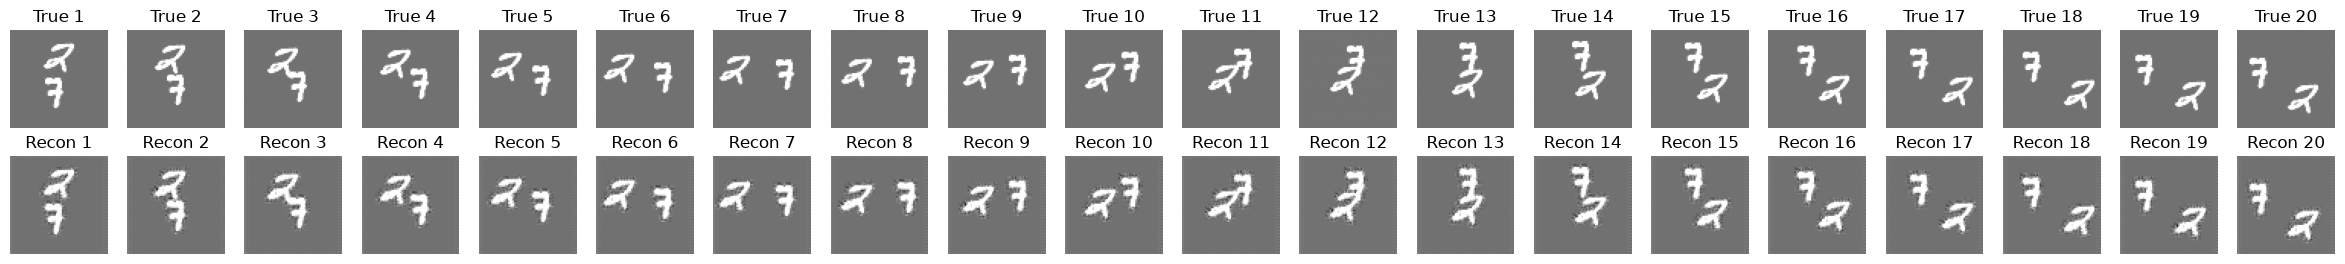

[A 046/060]  L_recon=0.00422  L_slow_raw=0.33092  λL_slow=0.01655  recon MSE=0.002674
[A 047/060]  L_recon=0.00415  L_slow_raw=0.32788  λL_slow=0.01639  recon MSE=0.002642
[A 048/060]  L_recon=0.00408  L_slow_raw=0.32491  λL_slow=0.01625  recon MSE=0.002612
[A 049/060]  L_recon=0.00401  L_slow_raw=0.32200  λL_slow=0.01610  recon MSE=0.002584
[A 050/060]  L_recon=0.00395  L_slow_raw=0.31916  λL_slow=0.01596  recon MSE=0.002558


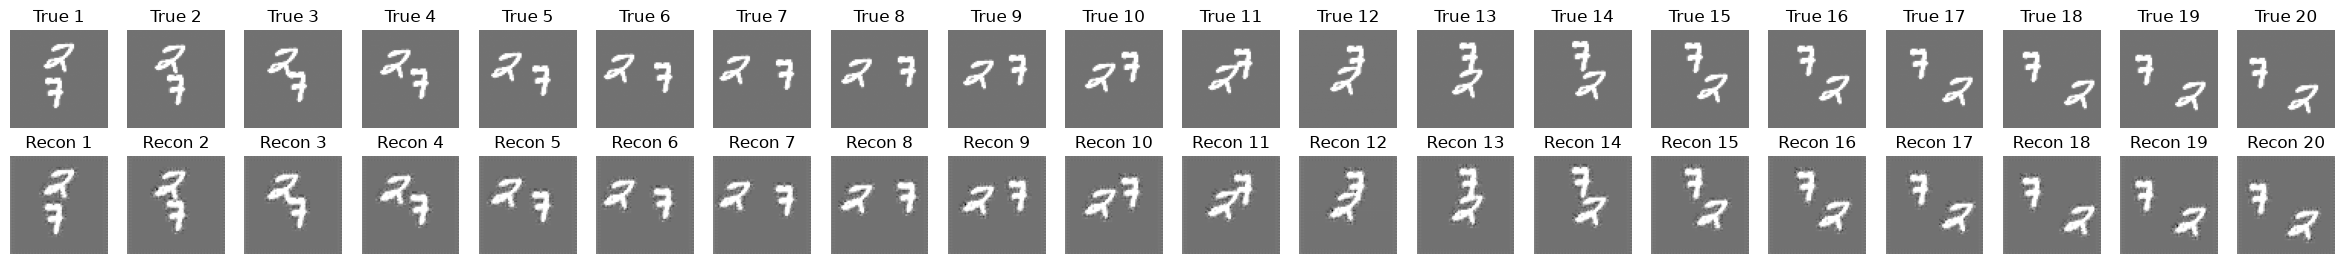

[A 051/060]  L_recon=0.00389  L_slow_raw=0.31638  λL_slow=0.01582  recon MSE=0.002533
[A 052/060]  L_recon=0.00383  L_slow_raw=0.31365  λL_slow=0.01568  recon MSE=0.002510
[A 053/060]  L_recon=0.00377  L_slow_raw=0.31098  λL_slow=0.01555  recon MSE=0.002488
[A 054/060]  L_recon=0.00371  L_slow_raw=0.30836  λL_slow=0.01542  recon MSE=0.002468
[A 055/060]  L_recon=0.00366  L_slow_raw=0.30578  λL_slow=0.01529  recon MSE=0.002449


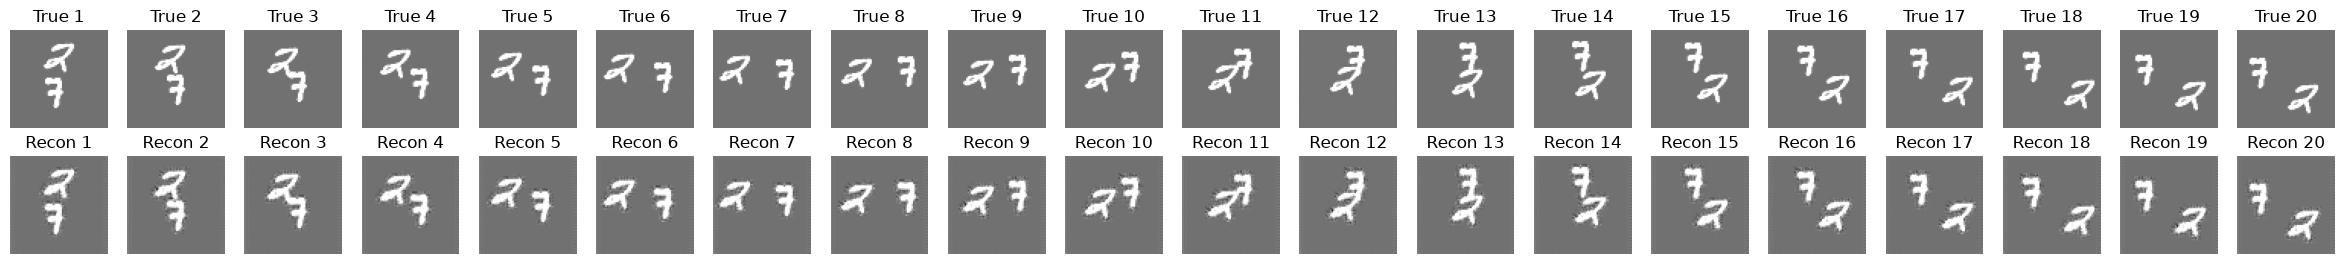

[A 056/060]  L_recon=0.00361  L_slow_raw=0.30325  λL_slow=0.01516  recon MSE=0.002432
[A 057/060]  L_recon=0.00356  L_slow_raw=0.30076  λL_slow=0.01504  recon MSE=0.002416
[A 058/060]  L_recon=0.00351  L_slow_raw=0.29831  λL_slow=0.01492  recon MSE=0.002401
[A 059/060]  L_recon=0.00346  L_slow_raw=0.29587  λL_slow=0.01479  recon MSE=0.002388


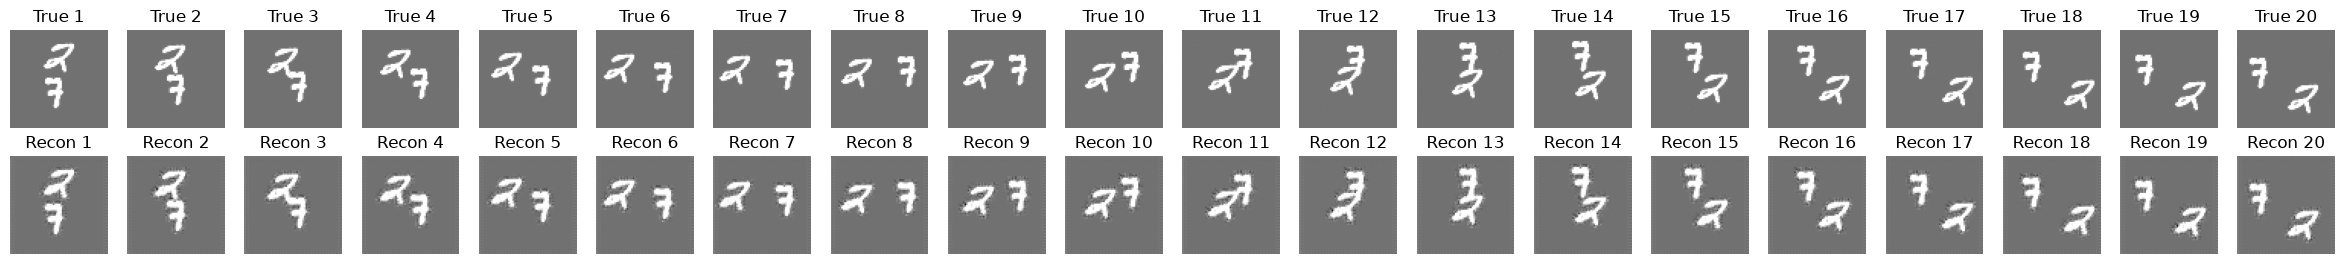


B. Latent smoothness [after stage A]
Same-frame cos=1.0000  (must be 1.0)

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.6667          0.8137     22.9731
   2          0.6838          0.7956     22.4438
   3          0.6883          0.7946     22.1390
   4          0.6509          0.8329     23.3590
   5          0.6895          0.7895     22.0616
   6          0.7551          0.6976     19.6208
   7          0.6151          0.8830     24.5261
   8          0.6450          0.8403     23.4729
   9          0.6254          0.8606     24.3212
  10          0.6326          0.8625     24.0831
  11          0.6704          0.8167     22.5400
  12          0.6526          0.8279     23.1662
  13          0.6599          0.8221     23.1512
  14          0.6401          0.8534     23.7553
  15          0.6457          0.8359     23.6033
  16          0.6260          0.8723     24.2238
  17          0.6127          0.8746     24.6016
  18          0.6665          0.8188     2

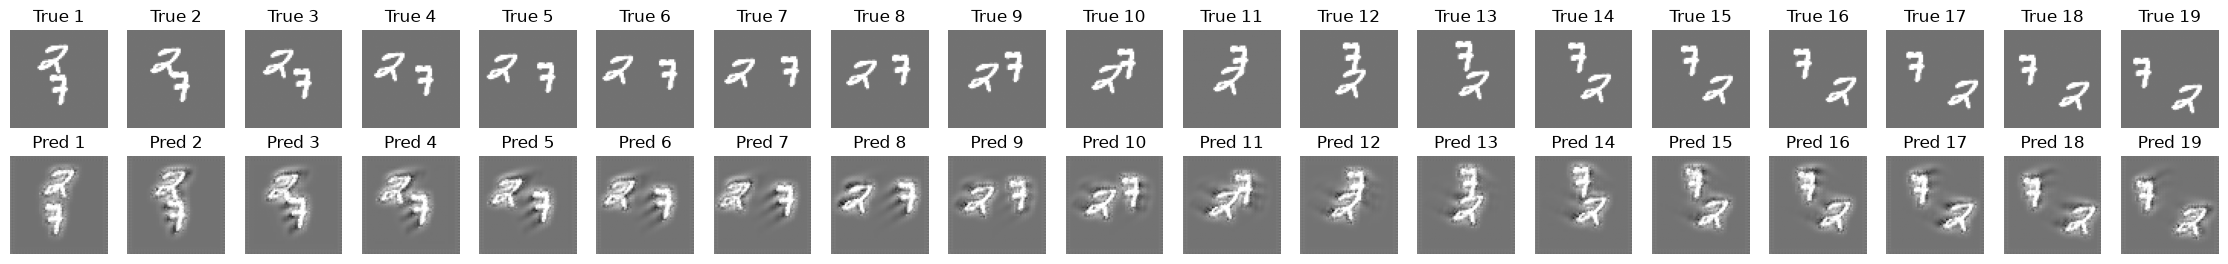

Identity check | ||delta||=16.048283  ||r_t-r_(t-1)||=31.838225  ratio=0.5041  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.032422  MSE(pred,true_(t-1))=0.024399  gap=+0.008023  COPY
[B 001/020]  r_noise=0.0026  ss_p=0.021  Next-frame MSE: 0.032422  train_δ-ratio=0.4640  val_δ-ratio=0.5041
Identity check | ||delta||=16.820489  ||r_t-r_(t-1)||=31.838225  ratio=0.5283  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.030457  MSE(pred,true_(t-1))=0.026140  gap=+0.004317  COPY
[B 002/020]  r_noise=0.0053  ss_p=0.042  Next-frame MSE: 0.030457  train_δ-ratio=0.5342  val_δ-ratio=0.5283
Identity check | ||delta||=17.266161  ||r_t-r_(t-1)||=31.838225  ratio=0.5423  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.029240  MSE(pred,true_(t-1))=0.026505  gap=+0.002734  COPY
[B 003/020]  r_noise=0.0079  ss_p=0.063  Next-frame MSE: 0.029240  train_δ-ratio=0.5446  val_δ-ratio=0.5423
Identity check | ||delta||=17.531574  ||r_t-r_(t-1)||=31.838225  ratio=0.5506  delta_scale=1.0
Copy-las

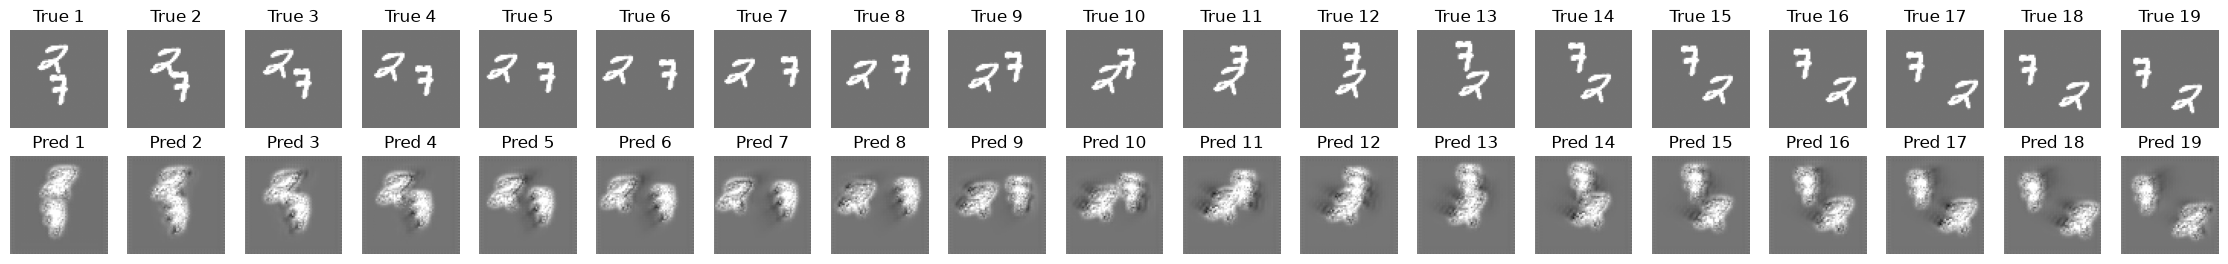

Identity check | ||delta||=18.047278  ||r_t-r_(t-1)||=31.838225  ratio=0.5668  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.027566  MSE(pred,true_(t-1))=0.027441  gap=+0.000125  COPY
[B 006/020]  r_noise=0.0158  ss_p=0.126  Next-frame MSE: 0.027566  train_δ-ratio=0.5712  val_δ-ratio=0.5668
Identity check | ||delta||=18.179074  ||r_t-r_(t-1)||=31.838225  ratio=0.5710  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.027276  MSE(pred,true_(t-1))=0.027474  gap=-0.000199  MOTION
[B 007/020]  r_noise=0.0184  ss_p=0.147  Next-frame MSE: 0.027276  train_δ-ratio=0.5752  val_δ-ratio=0.5710
Identity check | ||delta||=18.369202  ||r_t-r_(t-1)||=31.838225  ratio=0.5770  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.027099  MSE(pred,true_(t-1))=0.027702  gap=-0.000604  MOTION
[B 008/020]  r_noise=0.0211  ss_p=0.168  Next-frame MSE: 0.027099  train_δ-ratio=0.5715  val_δ-ratio=0.5770
Identity check | ||delta||=18.500928  ||r_t-r_(t-1)||=31.838225  ratio=0.5811  delta_scale=1.0
Copy

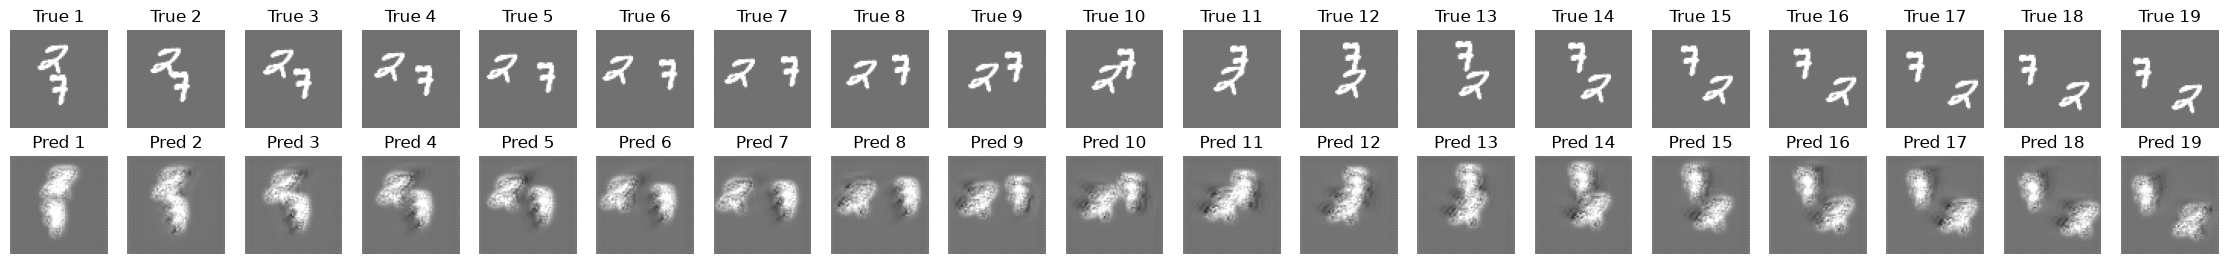

Identity check | ||delta||=18.671390  ||r_t-r_(t-1)||=31.838225  ratio=0.5864  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026804  MSE(pred,true_(t-1))=0.027537  gap=-0.000733  MOTION
[B 011/020]  r_noise=0.0289  ss_p=0.232  Next-frame MSE: 0.026804  train_δ-ratio=0.5395  val_δ-ratio=0.5864
Identity check | ||delta||=18.785196  ||r_t-r_(t-1)||=31.838225  ratio=0.5900  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026618  MSE(pred,true_(t-1))=0.027604  gap=-0.000986  MOTION
[B 012/020]  r_noise=0.0316  ss_p=0.253  Next-frame MSE: 0.026618  train_δ-ratio=0.5316  val_δ-ratio=0.5900
Identity check | ||delta||=18.827088  ||r_t-r_(t-1)||=31.838225  ratio=0.5913  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026617  MSE(pred,true_(t-1))=0.027613  gap=-0.000996  MOTION
[B 013/020]  r_noise=0.0342  ss_p=0.274  Next-frame MSE: 0.026617  train_δ-ratio=0.5229  val_δ-ratio=0.5913
Identity check | ||delta||=19.166745  ||r_t-r_(t-1)||=31.838225  ratio=0.6020  delta_scale=1.0
Co

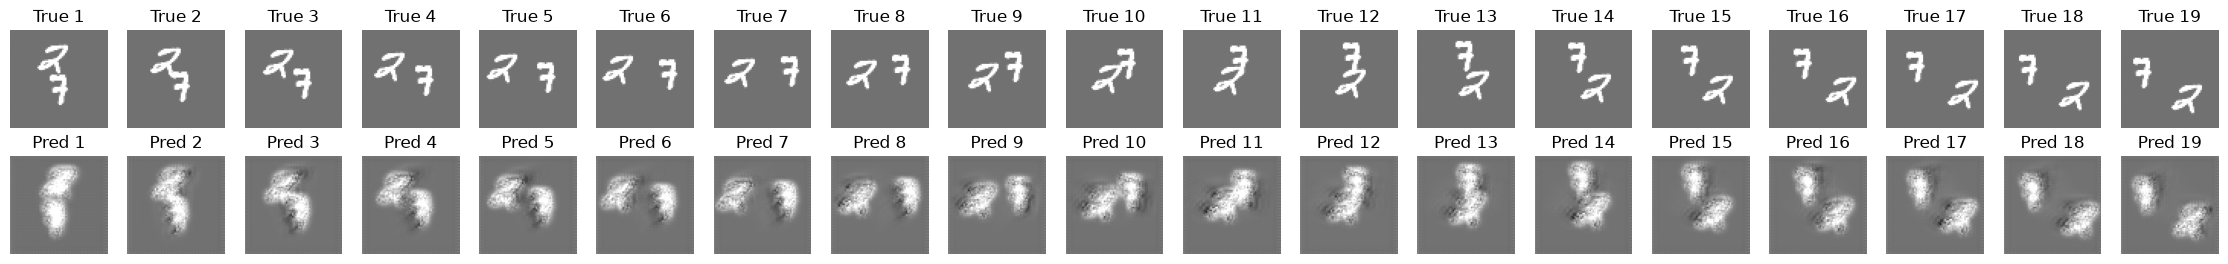

Identity check | ||delta||=19.011475  ||r_t-r_(t-1)||=31.838225  ratio=0.5971  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026614  MSE(pred,true_(t-1))=0.027836  gap=-0.001222  MOTION
[B 016/020]  r_noise=0.0421  ss_p=0.337  Next-frame MSE: 0.026614  train_δ-ratio=0.5097  val_δ-ratio=0.5971
Identity check | ||delta||=19.372828  ||r_t-r_(t-1)||=31.838225  ratio=0.6085  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026567  MSE(pred,true_(t-1))=0.027951  gap=-0.001383  MOTION
[B 017/020]  r_noise=0.0447  ss_p=0.358  Next-frame MSE: 0.026567  train_δ-ratio=0.4856  val_δ-ratio=0.6085
Identity check | ||delta||=18.940104  ||r_t-r_(t-1)||=31.838225  ratio=0.5949  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.026476  MSE(pred,true_(t-1))=0.027306  gap=-0.000830  MOTION
[B 018/020]  r_noise=0.0474  ss_p=0.379  Next-frame MSE: 0.026476  train_δ-ratio=0.4875  val_δ-ratio=0.5949
Identity check | ||delta||=19.507918  ||r_t-r_(t-1)||=31.838225  ratio=0.6127  delta_scale=1.0
Co

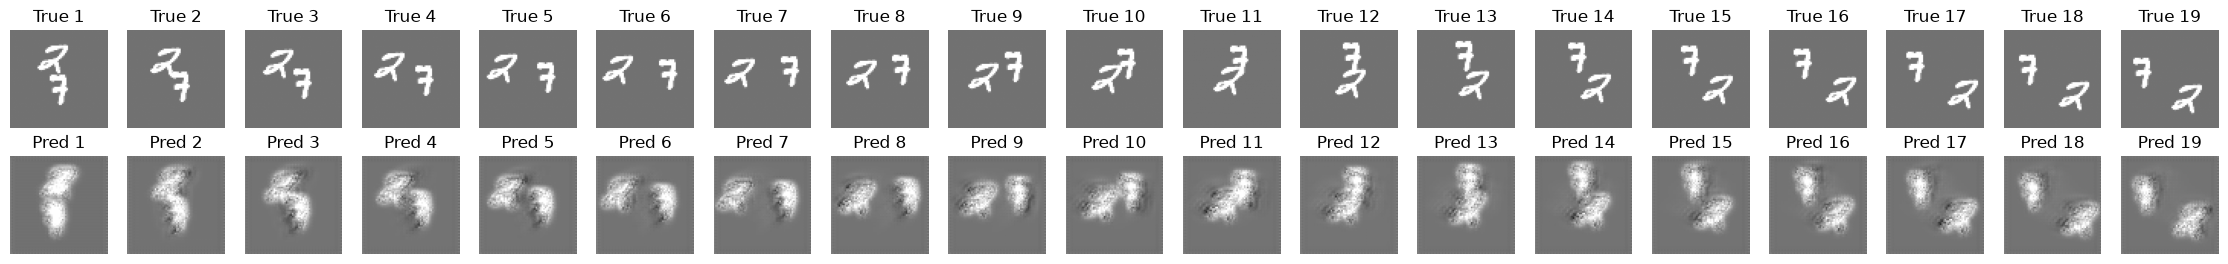


Post-train latent smoothness (frozen encoder):

B. Latent smoothness [after stage B]
Same-frame cos=1.0000  (must be 1.0)

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.6667          0.8137     22.9731
   2          0.6838          0.7956     22.4438
   3          0.6883          0.7946     22.1390
   4          0.6509          0.8329     23.3590
   5          0.6895          0.7895     22.0616
   6          0.7551          0.6976     19.6208
   7          0.6151          0.8830     24.5261
   8          0.6450          0.8403     23.4729
   9          0.6254          0.8606     24.3212
  10          0.6326          0.8625     24.0831
  11          0.6704          0.8167     22.5400
  12          0.6526          0.8279     23.1662
  13          0.6599          0.8221     23.1512
  14          0.6401          0.8534     23.7553
  15          0.6457          0.8359     23.6033
  16          0.6260          0.8723     24.2238
  17          0.6127          0.8746     24

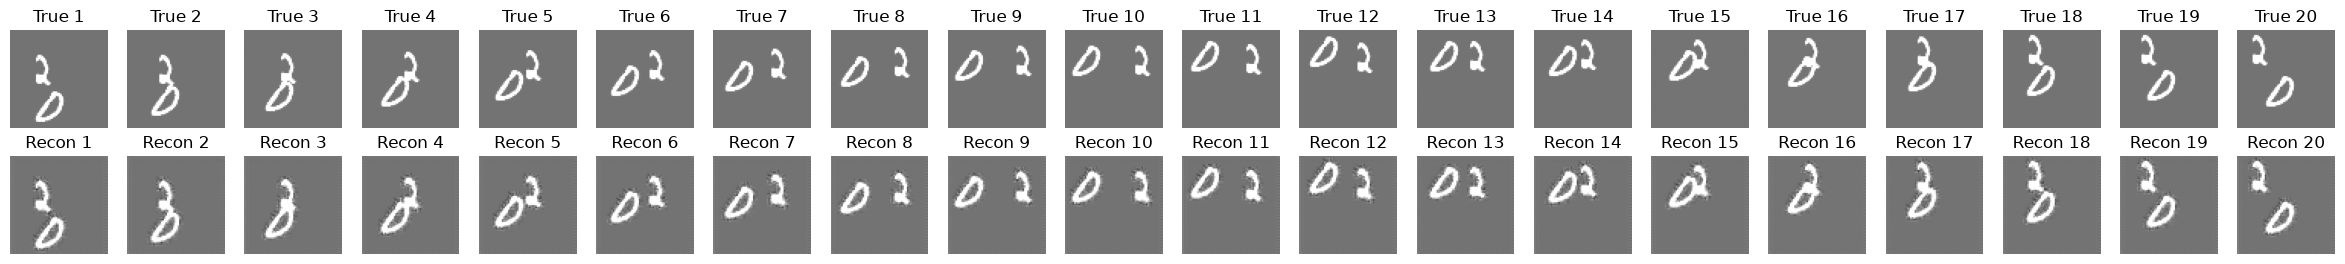

Identity check | ||delta||=19.155409  ||r_t-r_(t-1)||=31.999378  ratio=0.5986  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.024282  MSE(pred,true_(t-1))=0.026285  gap=-0.002003  MOTION
Validation  ->  Next-frame MSE: 0.024282  δ-ratio=0.5986  |  Per-frame: ['0.0293', '0.0206', '0.0217', '0.0253', '0.0239', '0.0228', '0.0228', '0.0248', '0.0245', '0.0278', '0.0247', '0.0302', '0.0250', '0.0215', '0.0213', '0.0214', '0.0253', '0.0233', '0.0252']


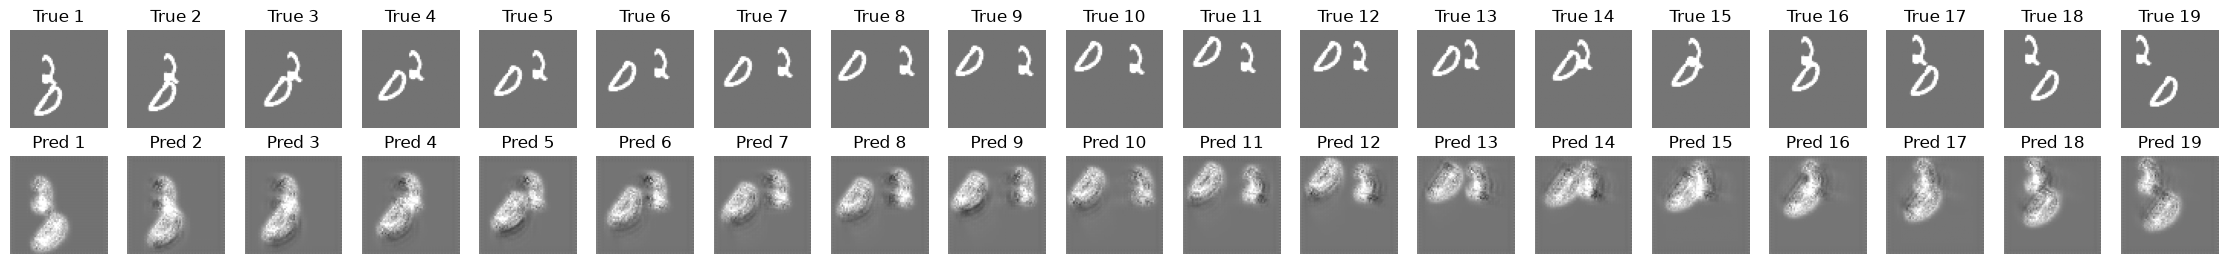

t=10 saturation | true: 0.0000 | substitute: 0.0000
Long-run  ->  MSE: 0.029872  |  Per-frame: ['0.0293', '0.0206', '0.0217', '0.0253', '0.0239', '0.0228', '0.0228', '0.0248', '0.0245', '0.0278', '0.0317', '0.0365', '0.0387', '0.0360', '0.0339', '0.0352', '0.0368', '0.0373', '0.0379']


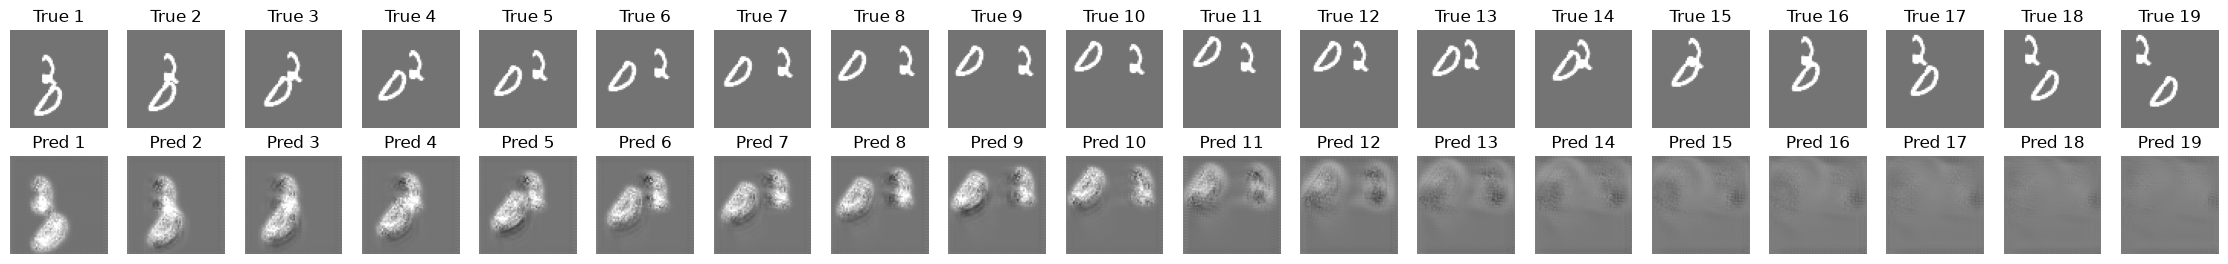

In [95]:
if __name__ == "__main__":
    main()
